# LSTM model

## Deploy TensorBoard

In [192]:
# tensorboard --logdir=src/model/lstm/lightning_logs

## Install libraries

In [193]:
# Standard libraries
import os
import random
import sys

# Third-party libraries
import ipynbname
import lightning as L
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from dotenv import load_dotenv
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset

# Project path setup
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

# Custom libraries
from dtos.config_dtos.config_dto import ConfigDto
from logger.logger import Logger
from utils.constants import *
from utils.utils import *

# from result_evaluator.result_evaluator import ResultEvaluator

# Torch serialization safe globals
torch.serialization.add_safe_globals(
    [ScalerType, ModelAchitectureType, OptimizerType, LossFunctionType]
)

In [194]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [195]:
import torch

print(f"GPU available: {torch.cuda.is_available()}")  # must be True
print(torch.cuda.get_device_name(0))  # NVIDIA GeForce RTX 3050

GPU available: True
NVIDIA GeForce RTX 3050 Laptop GPU


## Parameters

In [196]:
NOTEBOOK_NAME = ipynbname.name()
RANDOM_SEED = 18

STOCK_CODE = "VIC"
FEATURE_GROUPS = ["basic", "all_ta_function"]
LOOKBACK_WINDOW = 20
FORECAST_HORIZON = 5
STRIDE = 5
ID_COLUMN = ["date", "code"]
TARGET_COLUMN = "adjust"

# ── Training hyperparameters ──────────────────────────────────────────────────
MAX_EPOCHS = 1000
LEARNING_RATE = 3e-4
BATCH_SIZE = 32  # small batch — better noise with 518 samples
PATIENCE = 30
HIDDEN_SIZE = 64  # reduced from 128
NUM_LAYERS = 1  # reduced from 2
DROPOUT = 0.5  # increased from 0.2
WEIGHT_DECAY = 1e-3  # L2 regularization

## Load data

In [197]:
TRAIN_TEST_SET_STOCK_CODE = str.lower(
    f"../{TRAIN_TEST_SET_DIR}/{STOCK_CODE}_{LOOKBACK_WINDOW}_{FORECAST_HORIZON}_{STRIDE}"
)
TRAIN_TEST_SET_STOCK_CODE

'../../../train_test_set/vic_20_5_5'

In [198]:
selection_config = json.loads(
    open(f"{TRAIN_TEST_SET_STOCK_CODE}/selection_config.json", "r").read()
)

selection_config

{'N_FEATURES': 20,
 'n_original_features': 600,
 'top_features': [433,
  15,
  490,
  484,
  550,
  7,
  26,
  46,
  192,
  317,
  21,
  497,
  50,
  80,
  77,
  599,
  24,
  1,
  87,
  83],
 'LOOKBACK_WINDOW': 20,
 'FORECAST_HORIZON': 5,
 'STRIDE': 5,
 'has_overlap': False,
 'STOCK_CODE': 'vic',
 'train_shape': [518, 20, 20],
 'val_shape': [73, 20, 20],
 'test_shape': [73, 20, 20]}

In [199]:
INPUT_SIZE = selection_config["N_FEATURES"]
INPUT_SIZE

20

In [200]:
# ── Load selection config ─────────────────────────────────────────────────────
selection_config = json.loads(
    open(f"{TRAIN_TEST_SET_STOCK_CODE}/selection_config.json", "r").read()
)
print("Selection config:")
for k, v in selection_config.items():
    if k != "top_features":  # skip long list
        print(f"  {k:<25} : {v}")
print(f"  {'top_features':<25} : {len(selection_config['top_features'])} indices")
print()

# ── Derived constants ─────────────────────────────────────────────────────────
INPUT_SIZE = selection_config["N_FEATURES"]
LOOKBACK_WINDOW = selection_config["LOOKBACK_WINDOW"]
FORECAST_HORIZON = selection_config["FORECAST_HORIZON"]
STRIDE = selection_config["STRIDE"]
top_features = np.array(selection_config["top_features"])
has_overlap = selection_config["has_overlap"]

print(f"INPUT_SIZE       = {INPUT_SIZE}")
print(f"LOOKBACK_WINDOW  = {LOOKBACK_WINDOW}")
print(f"FORECAST_HORIZON = {FORECAST_HORIZON}")
print(f"STRIDE           = {STRIDE}")
print(f"has_overlap      = {has_overlap}")
print()

# ── Load metadata & date ranges ───────────────────────────────────────────────
with open(f"{TRAIN_TEST_SET_STOCK_CODE}/metadata.json", "r") as f:
    metadata = json.load(f)

train_range = metadata["train_range"]
val_range = metadata["val_range"]
test_range = metadata["test_range"]

print(f"train_range : {train_range}")
print(f"val_range   : {val_range}")
print(f"test_range  : {test_range}")
print()

# ── Load dates ────────────────────────────────────────────────────────────────
dates_train = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/dates_train.npy", allow_pickle=True)
dates_val = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/dates_val.npy", allow_pickle=True)
dates_test = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/dates_test.npy", allow_pickle=True)

# ── Load feature-selected tensors (for model) ─────────────────────────────────
X_tr = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/X_train_selected_tensor.npy")
X_vl = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/X_val_selected_tensor.npy")
X_te = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/X_test_selected_tensor.npy")

y_tr = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/y_train_selected_tensor.npy")
y_vl = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/y_val_selected_tensor.npy")
y_te = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/y_test_selected_tensor.npy")

d_tr = np.load(
    f"{TRAIN_TEST_SET_STOCK_CODE}/dates_train_selected.npy", allow_pickle=True
)
d_vl = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/dates_val_selected.npy", allow_pickle=True)
d_te = np.load(
    f"{TRAIN_TEST_SET_STOCK_CODE}/dates_test_selected.npy", allow_pickle=True
)

# ── Load full 600-feature tensors (for reference / data_evaluator) ────────────
X_train_tensor = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/X_train_tensor.npy")
X_val_tensor = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/X_val_tensor.npy")
X_test_tensor = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/X_test_tensor.npy")

y_train_tensor = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/y_train_tensor.npy")
y_val_tensor = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/y_val_tensor.npy")
y_test_tensor = np.load(f"{TRAIN_TEST_SET_STOCK_CODE}/y_test_tensor.npy")

train_featured_scaled_stock_tensor = np.load(
    f"{TRAIN_TEST_SET_STOCK_CODE}/train_featured_scaled_stock_tensor.npy"
)
val_featured_scaled_stock_tensor = np.load(
    f"{TRAIN_TEST_SET_STOCK_CODE}/val_featured_scaled_stock_tensor.npy"
)
test_featured_scaled_stock_tensor = np.load(
    f"{TRAIN_TEST_SET_STOCK_CODE}/test_featured_scaled_stock_tensor.npy"
)

# ── Load dataframes ───────────────────────────────────────────────────────────
train_featured_stock_df = pd.read_csv(
    f"{TRAIN_TEST_SET_STOCK_CODE}/train_featured_stock_df.csv"
)
val_featured_stock_df = pd.read_csv(
    f"{TRAIN_TEST_SET_STOCK_CODE}/val_featured_stock_df.csv"
)
test_featured_stock_df = pd.read_csv(
    f"{TRAIN_TEST_SET_STOCK_CODE}/test_featured_stock_df.csv"
)

# ── Summary ───────────────────────────────────────────────────────────────────
print("── Feature-selected tensors (for model) ────────────────────────────────")
print(f"  {'Split':<8} {'X shape':>20}  {'y shape':>10}  {'dates':>10}")
print(f"  {'-'*52}")
for name, X, y, d in [
    ("train", X_tr, y_tr, d_tr),
    ("val", X_vl, y_vl, d_vl),
    ("test", X_te, y_te, d_te),
]:
    print(f"  {name:<8} {str(X.shape):>20}  {str(y.shape):>10}  {str(d.shape):>10}")

print()
print("── Full tensors (600 features, for data_evaluator) ─────────────────────")
print(f"  {'Split':<8} {'X shape':>22}  {'y shape':>10}")
print(f"  {'-'*44}")
for name, X, y in [
    ("train", X_train_tensor, y_train_tensor),
    ("val", X_val_tensor, y_val_tensor),
    ("test", X_test_tensor, y_test_tensor),
]:
    print(f"  {name:<8} {str(X.shape):>22}  {str(y.shape):>10}")

print()
print("── Dataframes ───────────────────────────────────────────────────────────")
for name, df in [
    ("train", train_featured_stock_df),
    ("val", val_featured_stock_df),
    ("test", test_featured_stock_df),
]:
    print(f"  {name:<8} {df.shape}")

print()
print(f"── Key constant ─────────────────────────────────────────────────────────")
print(f"  INPUT_SIZE = {INPUT_SIZE}  ← pass this to LightningLSTM")

# ── Assert model will use correct data ────────────────────────────────────────
assert (
    X_tr.shape[2] == INPUT_SIZE
), f"X_tr feature dim {X_tr.shape[2]} ≠ INPUT_SIZE {INPUT_SIZE}"
assert (
    X_tr.shape[1] == LOOKBACK_WINDOW
), f"X_tr lookback {X_tr.shape[1]} ≠ LOOKBACK_WINDOW {LOOKBACK_WINDOW}"
print()
print("  ✓ Assertions passed — data is ready for model notebook")

Selection config:
  N_FEATURES                : 20
  n_original_features       : 600
  LOOKBACK_WINDOW           : 20
  FORECAST_HORIZON          : 5
  STRIDE                    : 5
  has_overlap               : False
  STOCK_CODE                : vic
  train_shape               : [518, 20, 20]
  val_shape                 : [73, 20, 20]
  test_shape                : [73, 20, 20]
  top_features              : 20 indices

INPUT_SIZE       = 20
LOOKBACK_WINDOW  = 20
FORECAST_HORIZON = 5
STRIDE           = 5
has_overlap      = False

train_range : ['2007-12-19', '2021-12-30']
val_range   : ['2022-01-04', '2023-12-28']
test_range  : ['2024-01-04', '2026-04-29']

── Feature-selected tensors (for model) ────────────────────────────────
  Split                 X shape     y shape       dates
  ----------------------------------------------------
  train           (518, 20, 20)      (518,)      (518,)
  val              (73, 20, 20)       (73,)       (73,)
  test             (73, 20, 20)       

In [201]:
CLIP_SIGMA = 3.0

print("── y clipping ───────────────────────────────────────────────────────────")
for name, arr in [("y_tr", y_tr), ("y_vl", y_vl), ("y_te", y_te)]:
    n_clipped = (np.abs(arr) > CLIP_SIGMA).sum()
    print(
        f"  {name}  values outside ±{CLIP_SIGMA}σ : {n_clipped}  "
        f"({n_clipped/len(arr):.1%})"
    )

y_tr_clip = np.clip(y_tr, -CLIP_SIGMA, CLIP_SIGMA)
y_vl_clip = np.clip(y_vl, -CLIP_SIGMA, CLIP_SIGMA)
y_te_clip = np.clip(y_te, -CLIP_SIGMA, CLIP_SIGMA)

print()
for name, arr in [
    ("y_tr_clip", y_tr_clip),
    ("y_vl_clip", y_vl_clip),
    ("y_te_clip", y_te_clip),
]:
    print(
        f"  {name}  mean={arr.mean():+.4f}  std={arr.std():.4f}  "
        f"min={arr.min():+.4f}  max={arr.max():+.4f}"
    )

── y clipping ───────────────────────────────────────────────────────────
  y_tr  values outside ±3.0σ : 8  (1.5%)
  y_vl  values outside ±3.0σ : 1  (1.4%)
  y_te  values outside ±3.0σ : 5  (6.8%)

  y_tr_clip  mean=-0.0185  std=0.8909  min=-3.0000  max=+3.0000
  y_vl_clip  mean=-0.2461  std=0.7454  min=-2.1409  max=+3.0000
  y_te_clip  mean=+0.2251  std=1.1460  min=-2.8527  max=+3.0000


## Create model

### Config Model

In [202]:
MODEL_ADDITIONAL_PARAMS = {
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "weight_decay": WEIGHT_DECAY,
    "loss": "huber",
}

config_dto = ConfigDto(
    notebook_name=NOTEBOOK_NAME,
    feature_groups=FEATURE_GROUPS,
    stock_code=STOCK_CODE,
    train_start_date=train_range[0],
    train_end_date=train_range[1],
    validation_start_date=val_range[0],
    validation_end_date=val_range[1],
    test_start_date=test_range[0],
    test_end_date=test_range[1],
    random_seed=RANDOM_SEED,
    lookback_window_size=LOOKBACK_WINDOW,
    forecast_window_size=FORECAST_HORIZON,
    stride=STRIDE,
    scaler_type=ScalerType.STANDARD,
    model_architecture=ModelAchitectureType.LSTM,
    model_additional_params=MODEL_ADDITIONAL_PARAMS,
    epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    optimizer=OptimizerType.ADAM,
    loss_fn=LossFunctionType.MSE,
    patience=PATIENCE,
)

config_dto.__dict__

{'notebook_name': 'lstm_vic_1',
 'feature_groups': ['basic', 'all_ta_function'],
 'stock_code': 'VIC',
 'train_start_date': '2007-12-19',
 'train_end_date': '2021-12-30',
 'validation_start_date': '2022-01-04',
 'validation_end_date': '2023-12-28',
 'test_start_date': '2024-01-04',
 'test_end_date': '2026-04-29',
 'random_seed': 18,
 'lookback_window_size': 20,
 'forecast_window_size': 5,
 'stride': 5,
 'scaler_type': <ScalerType.STANDARD: 'standard'>,
 'model_architecture': <ModelAchitectureType.LSTM: 'lstm'>,
 'model_additional_params': {'hidden_size': 64,
  'num_layers': 1,
  'dropout': 0.5,
  'weight_decay': 0.001,
  'loss': 'huber'},
 'epochs': 1000,
 'learning_rate': 0.0003,
 'batch_size': 32,
 'optimizer': <OptimizerType.ADAM: 'adam'>,
 'loss_fn': <LossFunctionType.MSE: 'mse'>,
 'patience': 30}

### Model

In [203]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L
from torch.optim import Adam
from dataclasses import asdict


class LightningLSTM(L.LightningModule):
    """
    Compact LSTM for 518-sample dataset.
    Key changes vs original:
      - hidden 128 → 32          (fewer params)
      - layers 2  → 1            (less capacity)
      - fc 4-layer → 2-layer     (32→16→1)
      - BatchNorm after LSTM      (stabilizes training)
      - Dropout 0.2 → 0.5        (stronger regularization)
      - MSE → Huber loss          (robust to outliers)
      - ReduceLROnPlateau         (adaptive learning rate)
      - val_r2 logged             (primary metric)
      - gradient_clip externally  (in Trainer)
    """

    def __init__(self, random_seed, input_size, config_dto: ConfigDto):
        super().__init__()
        L.seed_everything(seed=random_seed)

        self.input_size = int(input_size)
        if self.input_size <= 0:
            raise ValueError(f"input_size must be > 0, got {self.input_size}")

        self.lstm = nn.LSTM(
            input_size=self.input_size,
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            batch_first=True,
            dropout=0.0,
        )

        self.bn = nn.BatchNorm1d(HIDDEN_SIZE)

        self.fc = nn.Sequential(
            nn.Linear(HIDDEN_SIZE, 32),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(32, 1),
        )

        self.val_preds = []
        self.val_labels = []

        self.save_hyperparameters(asdict(config_dto))

    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # (B, T, hidden)
        x = lstm_out[:, -1, :]  # last timestep (B, hidden)
        x = self.bn(x)
        x = self.fc(x)  # (B, 1)
        return x.squeeze(-1)  # (B,)

    def configure_optimizers(self):
        optimizer = Adam(
            self.parameters(),
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=10,
            min_lr=1e-6,
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
            },
        }

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = F.huber_loss(self(x), y.float(), delta=2.0)  # was 1.0
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        pred = self(x)
        loss = F.huber_loss(pred, y.float(), delta=2.0)  # was 1.0
        self.log("val_loss", loss, prog_bar=True)
        self.val_preds.append(pred.detach())
        self.val_labels.append(y.detach().float())
        return loss

    def on_validation_epoch_end(self):
        preds = torch.cat(self.val_preds)
        labels = torch.cat(self.val_labels)
        ss_res = torch.sum((labels - preds) ** 2)
        ss_tot = torch.sum((labels - labels.mean()) ** 2)
        r2 = 1 - ss_res / (ss_tot + 1e-8)
        self.log("val_r2", r2, prog_bar=True)
        self.val_preds.clear()
        self.val_labels.clear()

In [204]:
from torch.utils.data import Dataset, DataLoader


class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


# ── IMPORTANT: use X_tr/vl/te from data_evaluator cell 6 ─────────────────────
# NOT X_train_tensor (600 features) — must be feature-selected (20 features)
assert X_tr.shape[2] == INPUT_SIZE, (
    f"X_tr has {X_tr.shape[2]} features but INPUT_SIZE={INPUT_SIZE}. "
    f"Run data_evaluator cell 6 first."
)

# Replace y_tr/vl/te with clipped versions in DataLoaders
train_loader = DataLoader(
    StockDataset(X_tr, y_tr_clip), batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(StockDataset(X_vl, y_vl_clip), batch_size=BATCH_SIZE)
test_loader = DataLoader(StockDataset(X_te, y_te_clip), batch_size=BATCH_SIZE)

print(f"train : {X_tr.shape}  y={y_tr.shape}")
print(f"val   : {X_vl.shape}  y={y_vl.shape}")
print(f"test  : {X_te.shape}  y={y_te.shape}")
print(f"INPUT_SIZE = {INPUT_SIZE}")

train : (518, 20, 20)  y=(518,)
val   : (73, 20, 20)  y=(73,)
test  : (73, 20, 20)  y=(73,)
INPUT_SIZE = 20


In [205]:
model = LightningLSTM(RANDOM_SEED, INPUT_SIZE, config_dto)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters : {n_params:,}")
print(f"Samples/params   : {len(y_tr)/n_params:.4f}×")
# Should be much less than 1 — regularization handles this
# Old model: ~200K params / 518 samples = 0.003×  (too many)
# New model: ~5K   params / 518 samples = 0.1×    (better)

Seed set to 18


Model parameters : 24,257
Samples/params   : 0.0214×


### Train model

In [206]:
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import CSVLogger

LOG_DIR = "D:/GIT/master-thesis/src/model/lstm/lightning_logs"
VERSION = 10  # bump each run

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    mode="min",
)

logger = CSVLogger(
    save_dir=LOG_DIR,
    name="",
    version=VERSION,
)

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    log_every_n_steps=1,
    callbacks=[early_stop],
    logger=logger,
    accelerator="gpu",
    gradient_clip_val=1.0,  # prevents exploding gradients
)

trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\fabric\loggers\csv_logs.py:268: Experiment logs directory D:/GIT/master-thesis/src/model/lstm/lightning_logs\version_10 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory D:/GIT/master-thesis/src/model/lstm/lightning_logs\version_10\checkpoints exists a


  | Name | Type        | Params | Mode  | FLOPs
-----------------------------------------------------
0 | lstm | LSTM        | 22.0 K | train | 0    
1 | bn   | BatchNorm1d | 128    | train | 0    
2 | fc   | Sequential  | 2.1 K  | train | 0    
-----------------------------------------------------
24.3 K    Trainable params
0         Non-trainable params
24.3 K    Total params
0.097     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops


d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 30: 100%|██████████| 17/17 [00:00<00:00, 94.76it/s, v_num=10, train_loss=0.495, val_loss=0.334, val_r2=-0.236]  


### Evaluate model

In [223]:
# In cell 7 evaluation — use clipped y for metrics
# Raw y_te still used for ResultEvaluator official metrics

from sklearn.metrics import r2_score
from scipy.stats import pearsonr

from evaluator.result_evaluator import ResultEvaluator

model.eval()
with torch.no_grad():
    y_pred_tr = model(torch.tensor(X_tr, dtype=torch.float32)).numpy()
    y_pred_vl = model(torch.tensor(X_vl, dtype=torch.float32)).numpy()
    y_pred_te = model(torch.tensor(X_te, dtype=torch.float32)).numpy()

print(f"  {'Split':<8} {'R2':>8} {'Pearson':>10} {'Dir acc':>10}  "
      f"{'pred_std/true_std':>18}")
print(f"  {'-'*60}")
for name, y_true, y_clip, y_hat in [
    ("train", y_tr, y_tr_clip, y_pred_tr),
    ("val",   y_vl, y_vl_clip, y_pred_vl),
    ("test",  y_te, y_te_clip, y_pred_te),
]:
    r2      = r2_score(y_clip, y_hat)
    corr, _ = pearsonr(y_clip, y_hat)
    da      = np.mean(np.sign(y_clip) == np.sign(y_hat))
    ratio   = y_hat.std() / y_clip.std()
    flag    = "✓" if r2 > 0 else "⚠"
    print(f"  {flag} {name:<6}  R2={r2:+.4f}  Pearson={corr:+.4f}  "
          f"dir_acc={da:.4f}  ratio={ratio:.3f}")

print()
# Official metrics use raw y_te (not clipped) for honest reporting
result_evaluator = ResultEvaluator(y_pred_te, y_te, d_te)
result_evaluator.evaluate()

  Split          R2    Pearson    Dir acc   pred_std/true_std
  ------------------------------------------------------------
  ✓ train   R2=+0.1605  Pearson=+0.4650  dir_acc=0.6409  ratio=0.230
  ⚠ val     R2=-0.2358  Pearson=-0.2100  dir_acc=0.4384  ratio=0.199
  ⚠ test    R2=-0.1148  Pearson=-0.0637  dir_acc=0.5205  ratio=0.122



,metric,value
0,MAE,1.066909
1,MSE,3.999063
2,RMSE,1.999766
3,MAPE,1.244264
4,R2,-0.114934


In [221]:
# Run this if val R2 is still negative after training
from sklearn.metrics import r2_score


print("── Diagnosis ────────────────────────────────────────────────────────────")
print(
    f"  Train R2  : {r2_score(y_tr, y_pred_tr):+.4f}  "
    f"(> 0.3 = model learned | > 0.8 = overfit)"
)
print(f"  Val R2    : {r2_score(y_vl, y_pred_vl):+.4f}  " f"(> 0 = generalizing)")
print(
    f"  Val dir   : {np.mean(np.sign(y_vl)==np.sign(y_pred_vl)):.4f}  "
    f"(> 0.52 = directional signal exists)"
)
print()

r2_train = r2_score(y_tr, y_pred_tr)
r2_val = r2_score(y_vl, y_pred_vl)
gap = r2_train - r2_val

if r2_train < 0.05:
    print("  → Underfitting: model not learning train set")
    print("    Try: increase hidden to 64, add 1 more fc layer")
elif gap > 1.0:
    print("  → Overfitting: train >> val")
    print("    Try: increase dropout to 0.6, weight_decay to 1e-2")
elif r2_val < 0 and gap < 0.5:
    print("  → Distribution shift: val period is structurally different")
    print(
        "    Expected for VIC 2022–2023 — use walk-forward CV (model_evaluator cell 7)"
    )
else:
    print("  → Signal is weak but model is behaving correctly")
    print("    Proceed to walk-forward CV for honest evaluation")

── Diagnosis ────────────────────────────────────────────────────────────
  Train R2  : +0.1402  (> 0.3 = model learned | > 0.8 = overfit)
  Val R2    : -0.1734  (> 0 = generalizing)
  Val dir   : 0.4384  (> 0.52 = directional signal exists)

  → Distribution shift: val period is structurally different
    Expected for VIC 2022–2023 — use walk-forward CV (model_evaluator cell 7)


In [209]:
# y_test_tensor[:10], y_test_tensor.shape

In [210]:
# y_pred = model(torch.tensor(X_test_tensor, dtype=torch.float32))
# y_pred = y_pred.detach().numpy()

# y_pred[:10], y_pred.shape

In [211]:
# dates_test[:10], dates_test.shape

In [212]:
# result_evaluator = ResultEvaluator(y_pred, y_test_tensor, dates_test)

In [213]:
# valuator = ResultEvaluator(y_pred, y_test_tensor, dates_test)

In [214]:
# result_evaluator.evaluate()

In [215]:
# result_folder = get_current_run_path()
# result_folder

In [216]:
# result_evaluator.save_result(result_folder)

## CHECK

In [217]:
# If these differ, the feature selection reindexed y incorrectly
print("Sign consistency check:")
print(f"  y_tr matches y_train_tensor : " f"{np.allclose(y_tr, y_train_tensor)}")
print(f"  y_vl matches y_val_tensor   : " f"{np.allclose(y_vl, y_val_tensor)}")
print(f"  y_te matches y_test_tensor  : " f"{np.allclose(y_te, y_test_tensor)}")
print()

# Check sign distribution
for name, arr in [("y_tr", y_tr), ("y_vl", y_vl), ("y_te", y_te)]:
    pct_pos = (arr > 0).mean()
    print(
        f"  {name}  UP={pct_pos:.2%}  DOWN={1-pct_pos:.2%}  "
        f"mean={arr.mean():+.4f}  std={arr.std():.4f}"
    )

Sign consistency check:
  y_tr matches y_train_tensor : True
  y_vl matches y_val_tensor   : True
  y_te matches y_test_tensor  : True

  y_tr  UP=41.70%  DOWN=58.30%  mean=-0.0000  std=1.0000
  y_vl  UP=27.40%  DOWN=72.60%  mean=-0.2258  std=0.8466
  y_te  UP=54.79%  DOWN=45.21%  mean=+0.4640  std=1.8939


In [218]:
# The feature selection sliced X_train_tensor[:, :, top_features]
# Verify this did not shift the time alignment
print("X/y alignment spot check:")
print(f"  X_tr[0] last date should match d_tr[0]")
print(f"  d_tr[0]  = {d_tr[0]}")
print(f"  d_tr[-1] = {d_tr[-1]}")
print(f"  d_vl[0]  = {d_vl[0]}")
print(f"  d_vl[-1] = {d_vl[-1]}")
print()

# Also confirm X shape is correct
print(f"  X_tr shape : {X_tr.shape}   expected (518, {LOOKBACK_WINDOW}, {INPUT_SIZE})")
print(f"  X_vl shape : {X_vl.shape}   expected  (73, {LOOKBACK_WINDOW}, {INPUT_SIZE})")

X/y alignment spot check:
  X_tr[0] last date should match d_tr[0]
  d_tr[0]  = 2008-01-18T00:00:00.000000000
  d_tr[-1] = 2021-12-17T00:00:00.000000000
  d_vl[0]  = 2022-02-09T00:00:00.000000000
  d_vl[-1] = 2023-12-19T00:00:00.000000000

  X_tr shape : (518, 20, 20)   expected (518, 20, 20)
  X_vl shape : (73, 20, 20)   expected  (73, 20, 20)


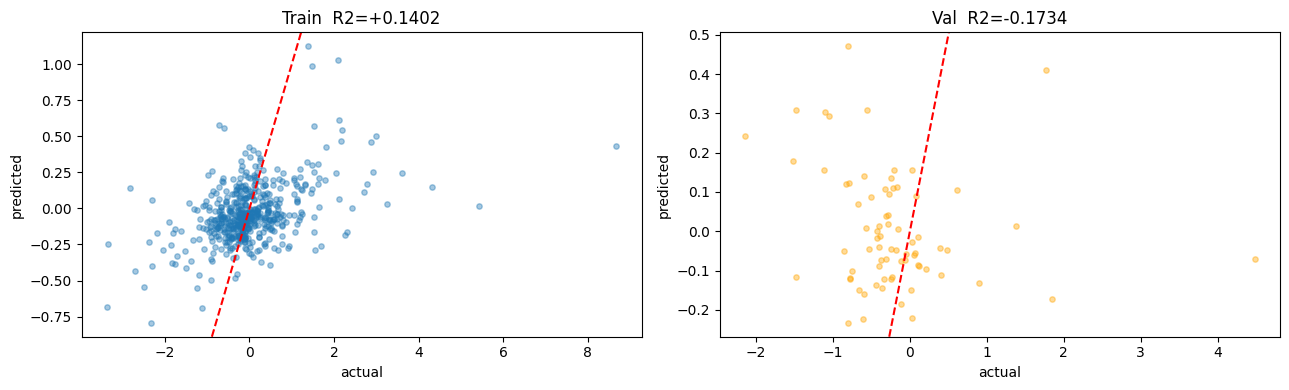

Prediction variance:
  train   mean=-0.0344  std=0.2047  min=-0.7938  max=+1.1252
  val     mean=+0.0041  std=0.1482  min=-0.2331  max=+0.4711
  test    mean=-0.1075  std=0.1404  min=-0.4163  max=+0.4998


In [219]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Train scatter
axes[0].scatter(y_tr, y_pred_tr, alpha=0.4, s=15)
axes[0].axline((0, 0), slope=1, color="red", linestyle="--")
axes[0].set_title(f"Train  R2={r2_score(y_tr, y_pred_tr):+.4f}")
axes[0].set_xlabel("actual")
axes[0].set_ylabel("predicted")

# Val scatter
axes[1].scatter(y_vl, y_pred_vl, alpha=0.4, s=15, color="orange")
axes[1].axline((0, 0), slope=1, color="red", linestyle="--")
axes[1].set_title(f"Val  R2={r2_score(y_vl, y_pred_vl):+.4f}")
axes[1].set_xlabel("actual")
axes[1].set_ylabel("predicted")

plt.tight_layout()
plt.show()

# Check if predictions are collapsed
print("Prediction variance:")
for name, y_hat in [("train", y_pred_tr), ("val", y_pred_vl), ("test", y_pred_te)]:
    print(
        f"  {name:<6}  mean={y_hat.mean():+.4f}  std={y_hat.std():.4f}  "
        f"min={y_hat.min():+.4f}  max={y_hat.max():+.4f}"
    )

In [220]:
# VIC 2022-2023 was a real-estate crash — returns were systematically negative
# If y_vl mean is very negative, the model predicting ~0 gives wrong direction
print("Val period analysis:")
print(
    f"  y_vl mean      : {y_vl.mean():+.4f}  "
    f"(in standardized units — 0 = same as train mean)"
)
print(f"  y_vl std       : {y_vl.std():.4f}")
print(f"  y_vl pct UP    : {(y_vl > 0).mean():.2%}")
print(f"  y_vl pct DOWN  : {(y_vl < 0).mean():.2%}")
print()
print("  If pct DOWN >> 50% and model predicts ~0 → dir acc < 50%")
print("  This is a regime shift issue, not a model bug")
print()

# Naive baseline: always predict 0 (train mean)
da_naive = np.mean(np.sign(y_vl) == np.sign(np.zeros_like(y_vl)))
print(f"  Naive dir acc (predict 0 always) : {da_naive:.4f}")
print(
    f"  Model dir acc                    : "
    f"{np.mean(np.sign(y_vl)==np.sign(y_pred_vl)):.4f}"
)
print()
print("  If naive > model → model is actively predicting wrong direction")
print("  If naive ≈ model → model is just collapsing to 0")

Val period analysis:
  y_vl mean      : -0.2258  (in standardized units — 0 = same as train mean)
  y_vl std       : 0.8466
  y_vl pct UP    : 27.40%
  y_vl pct DOWN  : 72.60%

  If pct DOWN >> 50% and model predicts ~0 → dir acc < 50%
  This is a regime shift issue, not a model bug

  Naive dir acc (predict 0 always) : 0.0000
  Model dir acc                    : 0.4384

  If naive > model → model is actively predicting wrong direction
  If naive ≈ model → model is just collapsing to 0
